In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

## Util functions

In [3]:
# model_name = 'deepseek-ai/DeepSeek-R1-Distill-Llama-8B'
model_name = 'openai/gpt-oss-20b'
layers = [14,15,16,17,18]
type = 'cot'
# Create output directory if it doesn't exist
activations_dir = os.path.join('../results', model_name, 'activations')
output_dir = os.path.join('../results', model_name, 'figures','pca')
os.makedirs(output_dir, exist_ok=True)


In [5]:
def set_plotting_settings():
    """Set matplotlib settings for better visualizations"""
    plt.rcParams['figure.figsize'] = (10, 8)
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.labelsize'] = 14
    plt.rcParams['axes.titlesize'] = 16
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    plt.rcParams['legend.fontsize'] = 12

def load_activations(file_path):
    """Load activation data from .npy file"""
    try:
        activations = np.load(file_path)
        print(f"Loaded activations with shape: {activations.shape}")
        return activations
    except Exception as e:
        print(f"Error loading file {file_path}: {e}")
        return None

def plot_pca_comparison(activations1, activations2, n_components=2, labels=None, output_file="pca_comparison.png"):
    """
    Plot PCA comparison of two sets of activations
    
    Args:
        activations1: First set of activations (numpy array)
        activations2: Second set of activations (numpy array)
        n_components: Number of PCA components to use
        labels: Labels for the two datasets
        title: Plot title
        output_file: Output file path
    """
    # Set plotting settings
    set_plotting_settings()
    
    # Combine activations for PCA fitting
    combined_activations = np.vstack([activations1, activations2])
    
    # Apply PCA
    pca = PCA(n_components=n_components)
    pca.fit(combined_activations)
    
    # Transform data
    activations1_pca = pca.transform(activations1)
    activations2_pca = pca.transform(activations2)
    
    # Create figure
    plt.figure(figsize=(10, 8))
    
    # Plot the first two components if n_components >= 2
    if n_components >= 2:
        # Plot activations1 points
        plt.scatter(
            activations1_pca[:, 0], 
            activations1_pca[:, 1], 
            color='blue', 
            alpha=0.6, 
            label=labels[0] if labels else "Activations 1"
        )
        
        # Plot activations2 points
        plt.scatter(
            activations2_pca[:, 0], 
            activations2_pca[:, 1], 
            color='red', 
            alpha=0.6, 
            label=labels[1] if labels else "Activations 2"
        )
        
        # Calculate and print explained variance
        explained_variance = pca.explained_variance_ratio_[:n_components]
        print(f"Explained variance ratio: {explained_variance}")
        print(f"Total explained variance: {sum(explained_variance):.4f}")
        
        # Print eigenvalues (variance explained in absolute terms)
        eigenvalues = pca.explained_variance_[:n_components]
        print(f"\nTop {n_components} eigenvalues:")
        for i, eigenval in enumerate(eigenvalues):
            print(f"  PC{i+1}: {eigenval:.4f}")
        
        # Add explained variance to axis labels
        plt.xlabel(f'PC 1 ({explained_variance[0]:.2%} variance)')
        plt.ylabel(f'PC 2 ({explained_variance[1]:.2%} variance)')
        
        # Add title and legend
        plt.legend()
        
        # Add grid
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # Save figure
        plt.tight_layout()
        plt.savefig(output_file, dpi=300)
        print(f"Saved PCA plot to {output_file}")
        
        # Display figure
        plt.show()
        
        return {
            "pca": pca,
            "activations1_pca": activations1_pca,
            "activations2_pca": activations2_pca,
            "explained_variance": explained_variance,
            "eigenvalues": eigenvalues
        }
    else:
        print("Need at least 2 components to create a 2D plot")
        return None

def analyze_pca_components(pca, n_top_features=10):
    """
    Analyze what features contribute most to each principal component
    
    Args:
        pca: Fitted PCA object
        n_top_features: Number of top features to show
    """
    feature_importance = {}
    
    for i, component in enumerate(pca.components_):
        # Get the indices of the n_top_features with the largest absolute values
        sorted_indices = np.argsort(np.abs(component))[::-1]
        top_indices = sorted_indices[:n_top_features]
        
        # Store the feature indices and their importance scores
        feature_importance[f"PC{i+1}"] = [(idx, component[idx]) for idx in top_indices]
        
        print(f"\nTop features for PC{i+1}:")
        for idx, value in feature_importance[f"PC{i+1}"]:
            print(f"  Feature {idx}: {value:.4f}")
    
    return feature_importance

Loaded activations with shape: (21, 2880)
Loaded activations with shape: (21, 2880)
Explained variance ratio: [0.4042576  0.08682011]
Total explained variance: 0.4911

Top 2 eigenvalues:
  PC1: 62877.2266
  PC2: 13503.7852
Saved PCA plot to ../results/openai/gpt-oss-20b/figures/pca/pca_14_cot_activations.png


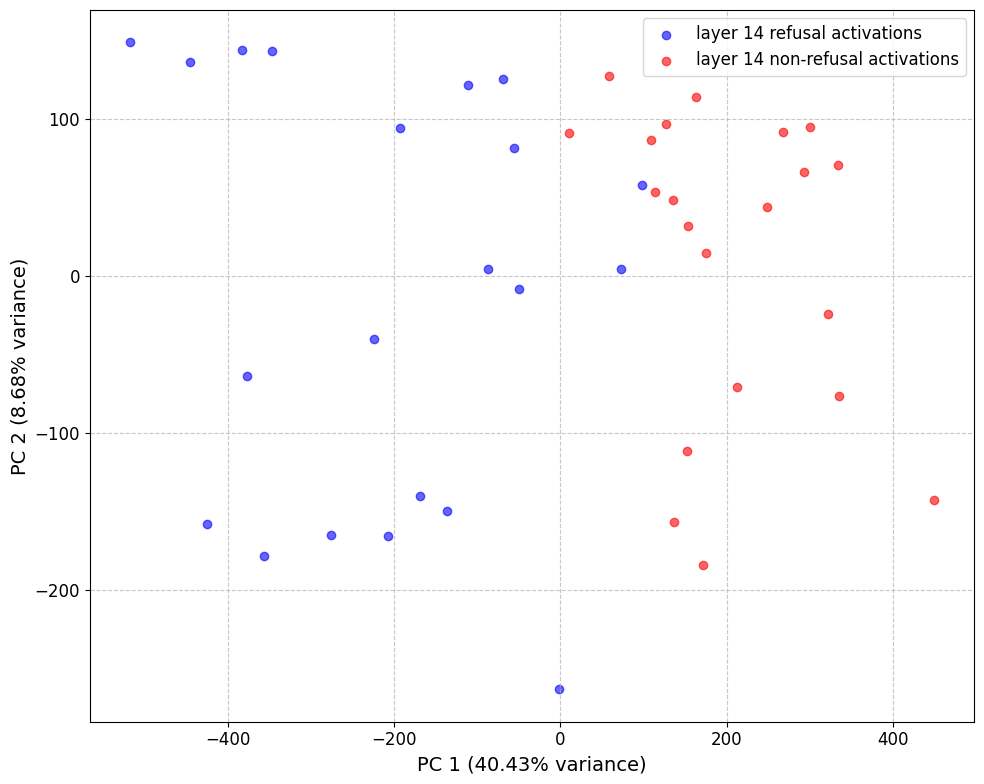


Top features for PC1:
  Feature 1372: 0.2330
  Feature 1167: 0.2289
  Feature 2152: -0.2008
  Feature 488: -0.1309
  Feature 1452: 0.1249
  Feature 773: -0.1240
  Feature 1118: 0.1229
  Feature 2683: -0.1111
  Feature 2326: -0.1100
  Feature 494: -0.0979

Top features for PC2:
  Feature 192: 0.1118
  Feature 2559: 0.1110
  Feature 744: -0.1005
  Feature 86: 0.0880
  Feature 211: -0.0812
  Feature 2555: 0.0788
  Feature 488: 0.0760
  Feature 2152: 0.0734
  Feature 2214: -0.0721
  Feature 587: 0.0713
Loaded activations with shape: (21, 2880)
Loaded activations with shape: (21, 2880)
Explained variance ratio: [0.41665816 0.09740178]
Total explained variance: 0.5141

Top 2 eigenvalues:
  PC1: 91093.5156
  PC2: 21294.8457
Saved PCA plot to ../results/openai/gpt-oss-20b/figures/pca/pca_15_cot_activations.png


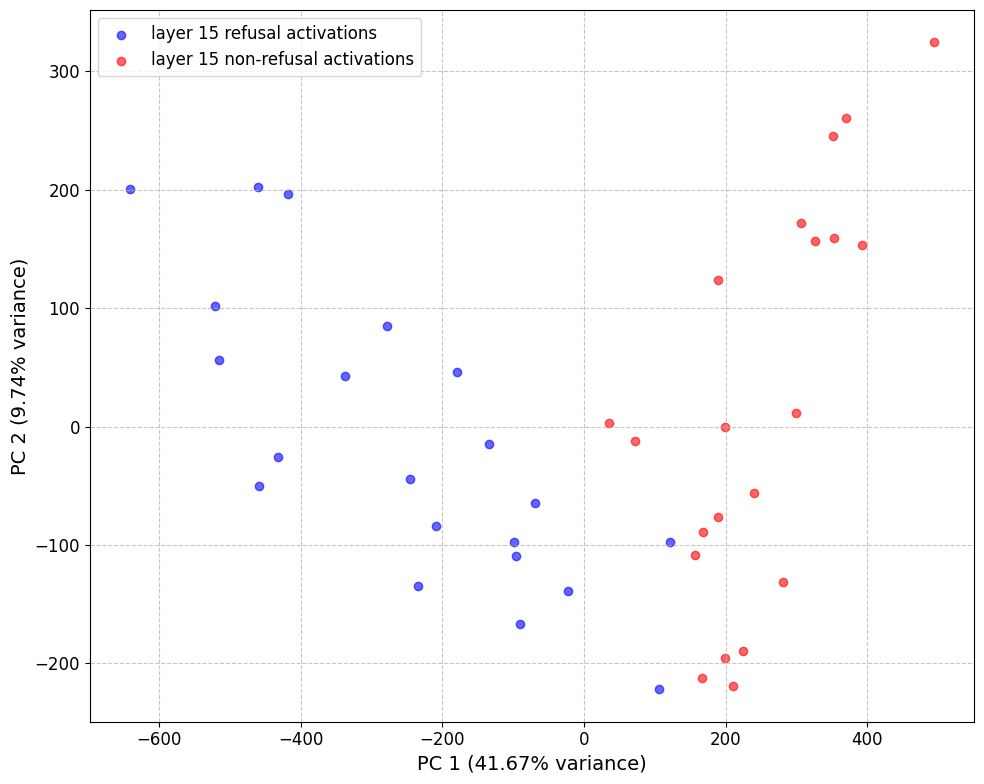


Top features for PC1:
  Feature 1372: 0.2026
  Feature 1167: 0.2016
  Feature 2152: -0.1857
  Feature 494: -0.1700
  Feature 759: 0.1697
  Feature 2559: -0.1293
  Feature 1506: -0.1217
  Feature 488: -0.1176
  Feature 1118: 0.1091
  Feature 2683: -0.1008

Top features for PC2:
  Feature 2559: 0.1911
  Feature 1168: -0.1876
  Feature 1506: 0.1646
  Feature 1896: -0.1497
  Feature 1444: 0.1258
  Feature 759: -0.1137
  Feature 2805: -0.1035
  Feature 689: 0.1026
  Feature 1644: -0.0917
  Feature 1372: 0.0884
Loaded activations with shape: (21, 2880)
Loaded activations with shape: (21, 2880)
Explained variance ratio: [0.4075149  0.10391204]
Total explained variance: 0.5114

Top 2 eigenvalues:
  PC1: 134252.9531
  PC2: 34233.1016
Saved PCA plot to ../results/openai/gpt-oss-20b/figures/pca/pca_16_cot_activations.png


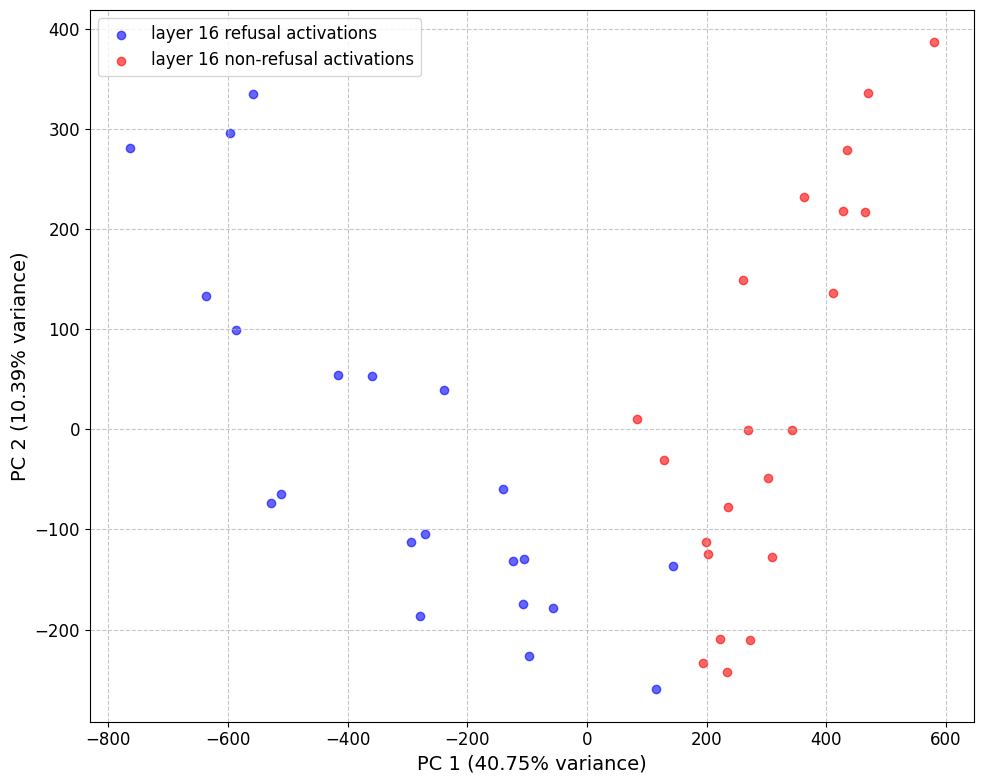


Top features for PC1:
  Feature 1167: 0.2321
  Feature 494: -0.2005
  Feature 1372: 0.1694
  Feature 2152: -0.1514
  Feature 773: -0.1285
  Feature 1444: -0.1163
  Feature 488: -0.1022
  Feature 465: -0.1003
  Feature 481: -0.0874
  Feature 1118: 0.0865

Top features for PC2:
  Feature 1444: 0.1739
  Feature 1168: -0.1526
  Feature 1896: -0.1284
  Feature 494: 0.1107
  Feature 773: 0.0924
  Feature 2647: -0.0809
  Feature 2805: -0.0785
  Feature 689: 0.0782
  Feature 1644: -0.0748
  Feature 465: -0.0744
Loaded activations with shape: (21, 2880)
Loaded activations with shape: (21, 2880)
Explained variance ratio: [0.42392775 0.11335327]
Total explained variance: 0.5373

Top 2 eigenvalues:
  PC1: 240212.1250
  PC2: 64229.8789
Saved PCA plot to ../results/openai/gpt-oss-20b/figures/pca/pca_17_cot_activations.png


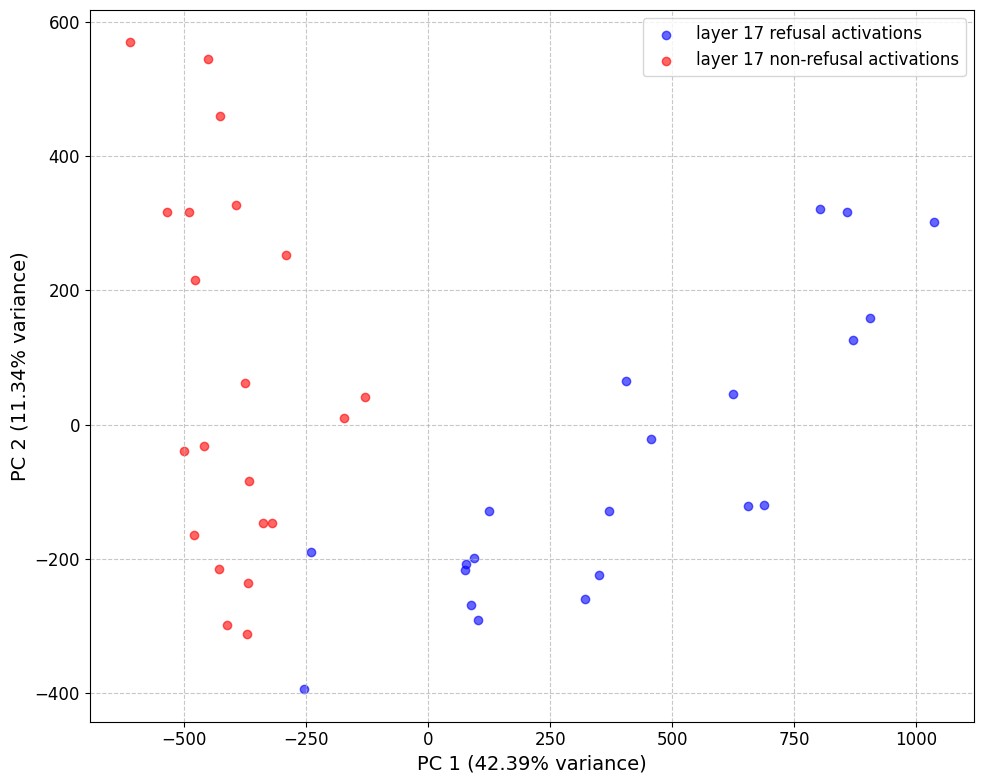


Top features for PC1:
  Feature 494: 0.2065
  Feature 1444: 0.2040
  Feature 759: -0.1972
  Feature 1167: -0.1917
  Feature 193: -0.1699
  Feature 1506: 0.1400
  Feature 886: 0.1327
  Feature 1372: -0.1282
  Feature 2152: 0.1171
  Feature 481: 0.1074

Top features for PC2:
  Feature 1444: 0.1994
  Feature 494: 0.1599
  Feature 1168: -0.1264
  Feature 193: -0.1152
  Feature 808: 0.1136
  Feature 1506: 0.1106
  Feature 1896: -0.1069
  Feature 2647: -0.1034
  Feature 773: -0.0994
  Feature 886: 0.0889
Loaded activations with shape: (21, 2880)
Loaded activations with shape: (21, 2880)
Explained variance ratio: [0.36421424 0.12397248]
Total explained variance: 0.4882

Top 2 eigenvalues:
  PC1: 363083.8438
  PC2: 123587.7188
Saved PCA plot to ../results/openai/gpt-oss-20b/figures/pca/pca_18_cot_activations.png


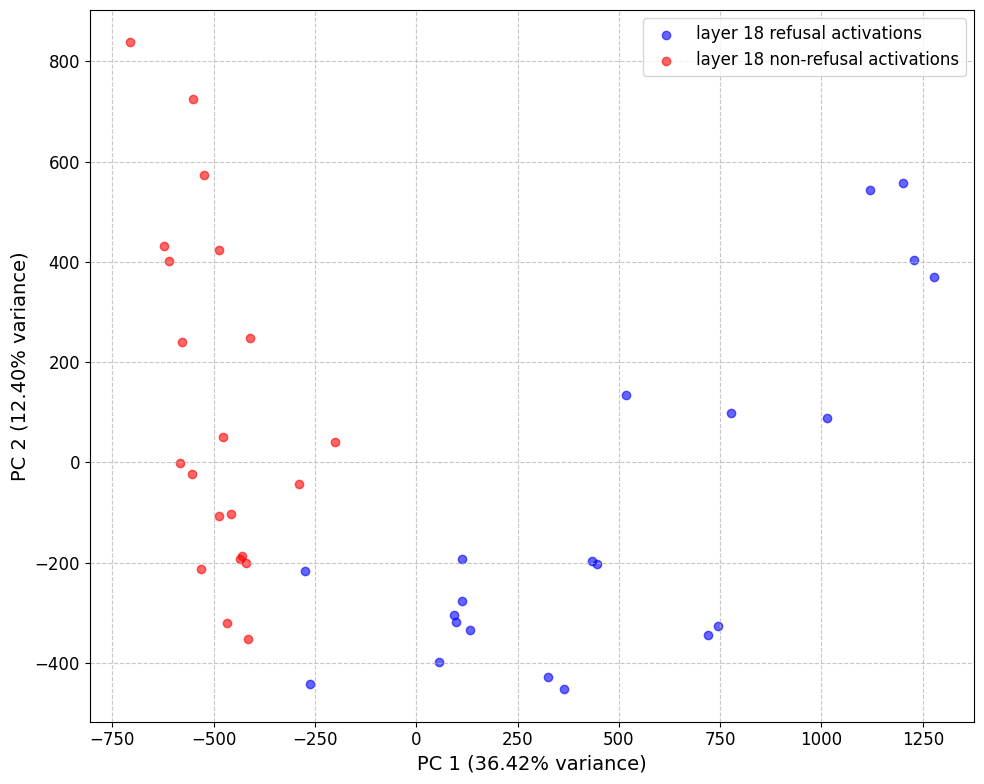


Top features for PC1:
  Feature 1444: 0.2244
  Feature 494: 0.2057
  Feature 1167: -0.1774
  Feature 1200: -0.1499
  Feature 759: -0.1473
  Feature 773: 0.1164
  Feature 2559: -0.1140
  Feature 2335: -0.1020
  Feature 1372: -0.1007
  Feature 465: 0.0955

Top features for PC2:
  Feature 1444: 0.2085
  Feature 494: 0.1581
  Feature 1711: -0.1404
  Feature 138: 0.0913
  Feature 1413: -0.0885
  Feature 1168: -0.0877
  Feature 1140: 0.0865
  Feature 1375: -0.0843
  Feature 1433: 0.0843
  Feature 2647: -0.0804


In [6]:
def main():
    ndims = 2
    
    for layer in layers:
        # Load activations
        activations_refusal = load_activations(os.path.join(activations_dir, 'refusal', f"layer_{layer}_{type}_activations.npy"))
        activations_nonrefusal = load_activations(os.path.join(activations_dir, 'non_refusal', f"layer_{layer}_{type}_activations.npy"))
        
        if activations_refusal is None or activations_nonrefusal is None:
            print("Failed to load one or both activation files. Exiting.")
            return
        
        # Check dimensions
        if activations_refusal.shape != activations_nonrefusal.shape:
            print(f"Warning: Activation shapes don't match - {activations_refusal.shape} vs {activations_nonrefusal.shape}")
        
        labels = [f"layer {layer} refusal activations", f"layer {layer} non-refusal activations"]
        
        # Plot PCA comparison
        result = plot_pca_comparison(
            activations_refusal, 
            activations_nonrefusal, 
            n_components=ndims,
            labels=labels,
            output_file=os.path.join(output_dir, f"pca_{layer}_{type}_activations.png")
        )
        
        # Analyze PCA components if requested
        if result:
            analyze_pca_components(result["pca"])

main()